# Random Forest 구현

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 데이터 읽어오기

In [31]:
wine = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/winequalityN.csv')

In [4]:
wine.shape

(6497, 13)

In [5]:
wine.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [7]:
wine['type'].value_counts()

,count
type,
white,4898
red,1599


### Target = y값 = type = whte & red

## EDA

In [6]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


### quality는 3~9 이므로 encoding 필요할듯.


In [11]:
print(wine.isna().sum())

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64


### 항목별로 결측치들은 평균으로 채우자.

train의 평균으로 test까지 채워줄 것

In [10]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## Train, Test 분리

In [32]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(wine, test_size=0.2, random_state=SEED, shuffle=True)
x_train = train.drop(['type'], axis=1)
y_train = train['type']
x_test = test.drop(['type'], axis=1)
y_test = test['type']

## 데이터 전처리

### 결측치 채우기

In [33]:
cols_w_na = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'pH', 'sulphates']
for col in cols_w_na:
  m = x_train[col].mean()
  x_train[col] = x_train[col].fillna(m)
  x_test[col] = x_test[col].fillna(m)


### Encoding

#### x

In [34]:
from sklearn.preprocessing import OneHotEncoder

x_categorical_cols = ['quality']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
x_ohe = pd.DataFrame(
                    data = ohe.fit_transform(x_train[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_train.index
                    )

x_train_e = pd.concat([x_train.drop(x_categorical_cols, axis=1), x_ohe], axis=1)

#### y

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_e = le.fit_transform(y_train)

### Scaling

x만 필요

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train_e)
x_train_es = scaler.transform(x_train_e)

## 모델 학습

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

clf = RandomForestClassifier(random_state=SEED)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train_es, y_train_e)

best_model_rf = grid_search.best_estimator_

## 테스트

### 전처리

#### Encoding

In [38]:
x_ohe_test = pd.DataFrame(
                    data = ohe.transform(x_test[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_test.index
                    )

x_test_e = pd.concat([x_test.drop(x_categorical_cols, axis=1), x_ohe_test], axis=1)

In [39]:
y_test_e = le.transform(y_test)

#### Scaling

In [40]:
x_test_es = scaler.transform(x_test_e)

### test

In [41]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)    # 맞힌 개수 / 전체 개수
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred, average='macro')     # TP / (TP + FN)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred, average='macro')    # TP / (TP + FP)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred, average='macro')       # (2 * Precision * Recall) / (Precision + Recall)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

1. Accuracy: 0.9969
2. Recall: 0.9936
3. Precision: 0.9980
4. F1 Score: 0.9958


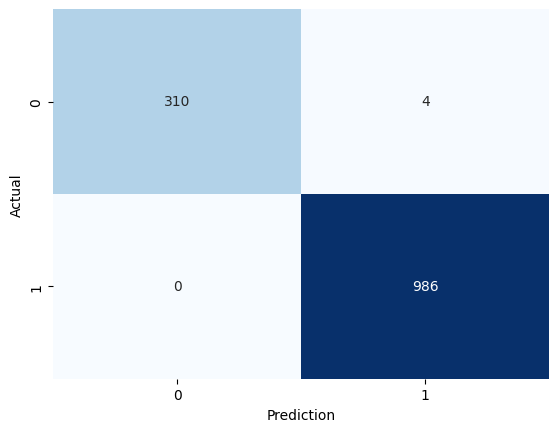

In [42]:
y_predict_rf = best_model_rf.predict(x_test_es)

print_metrics(y_test_e, y_predict_rf)